# Задачи к Лекции 1

Дан файл "athlete_events", который содержит информацию об олимпийских чемпионах за последние 120 лет.

**Чтение данных**

При загрузке оставляем только информацию о призерах с данными без пропусков.

In [2]:
%matplotlib inline
import zipfile
import numpy as np
import pandas as pd
import seaborn as sns

#z = zipfile.ZipFile("/content/athlete_events.csv")
df = pd.read_csv("athlete_events.csv")
df = df.dropna(subset=['Medal', "Age", "Height", "Weight"])
df.head()

df['NOC'] = df['NOC'].replace({
    'URS': 'RUS'
}) #объединяем СССР и РФ

FileNotFoundError: [Errno 2] No such file or directory: 'athlete_events.csv'

**Получение различной информации**

In [ ]:
df.shape

(30181, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30181 entries, 40 to 271103
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      30181 non-null  int64  
 1   Name    30181 non-null  object 
 2   Sex     30181 non-null  object 
 3   Age     30181 non-null  float64
 4   Height  30181 non-null  float64
 5   Weight  30181 non-null  float64
 6   Team    30181 non-null  object 
 7   NOC     30181 non-null  object 
 8   Games   30181 non-null  object 
 9   Year    30181 non-null  int64  
 10  Season  30181 non-null  object 
 11  City    30181 non-null  object 
 12  Sport   30181 non-null  object 
 13  Event   30181 non-null  object 
 14  Medal   30181 non-null  object 
dtypes: float64(3), int64(2), object(10)
memory usage: 3.7+ MB


In [ ]:
df.describe()

,ID,Age,Weight,Year
count,4106.000000,4106.000000,4106.000000,4106.000000
mean,10771.467608,25.488310,73.965660,1988.455431
std,5845.870321,5.063349,15.458472,22.532047
min,16.000000,14.000000,32.000000,1896.000000
25%,5971.000000,22.000000,63.000000,1976.000000
50%,10618.000000,25.000000,73.000000,1992.000000
75%,15627.000000,28.000000,83.000000,2006.000000
max,21303.000000,58.000000,170.000000,2016.000000


**1. Сколько мужчин и женщин получили золотые, серебрянные и бронзовые медали?**

In [ ]:
# Your code here
df.groupby(['Medal', 'Sex'])['Sex'].count()

Medal   Sex
Bronze  F      3475
        M      6673
Gold    F      3437
        M      6730
Silver  F      3438
        M      6428
Name: Sex, dtype: int64

**2. Какая страна получила наибольшее количество золотых медалей за всю историю олимпийских игр?**

In [ ]:
# Your code here
df[df['Medal'] == 'Gold'].groupby('Team')['Medal'].count().sort_values(ascending=False).head(1)

,Medal
Team,
United States,2075


**3. Выведите распределение пола участника олимпиады от вида спорта (crosstab)**

In [ ]:
# Your code here
pd.crosstab(df['Sport'], df['Sex'])

Sex,F,M
Sport,,
Alpine Skiing,180,174
Archery,100,106
Art Competitions,0,2
Athletics,1239,2409
Badminton,73,81
Baseball,0,333
Basketball,390,610
Beach Volleyball,35,33
Biathlon,147,241


**4. Выведите средний возраст и его стандартное отклонения для женщин, учавствовавших в хоккее на льду**

In [ ]:
# Your code here
df[(df['Sex'] == 'F') & (df['Sport'] == 'Ice Hockey')]['Age'].agg(['mean', 'std'])

,Age
mean,24.420000
std,4.360464


**5. У какой страны больше всего было больше всего женщин, получивших бронзовую медаль?**

In [ ]:
# Your code here
df[(df['Sex'] == 'F') & (df['Medal'] == 'Bronze')].groupby('Team').size().sort_values(ascending=False).head(1)

,0
Team,
United States,360


**6. Постройте гистограмму распределения количества медалей (бронза, серебро, золото) для первых трех стран, получивших наибольшее количество медалей**

<Axes: xlabel='Team', ylabel='count'>

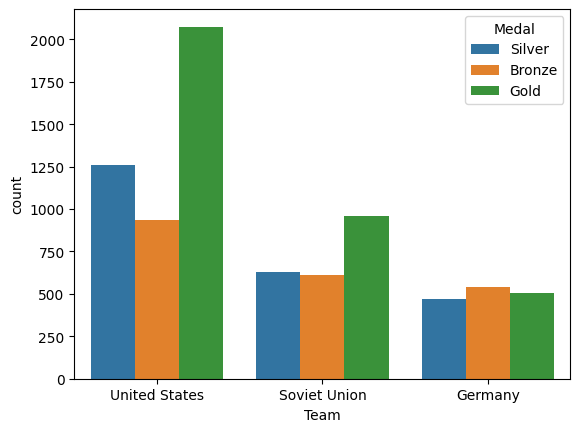

In [ ]:
# Your code here
top3 = (
    df[df['Medal'].notna()]['Team']
    .value_counts()
    .head(3)
    .index
)

# Оставляем только эти 3 страны и строки с медалями
medals_top3 = df[
    (df['Team'].isin(top3)) &
    (df['Medal'].notna())
]

# Строим график
sns.countplot(
    data=medals_top3,
    x='Team',
    hue='Medal'
)



**7. Нарисуйте распределение веса мужчин, получивших серебрянную медаль(density или distplot)**

<Axes: xlabel='Weight', ylabel='Count'>

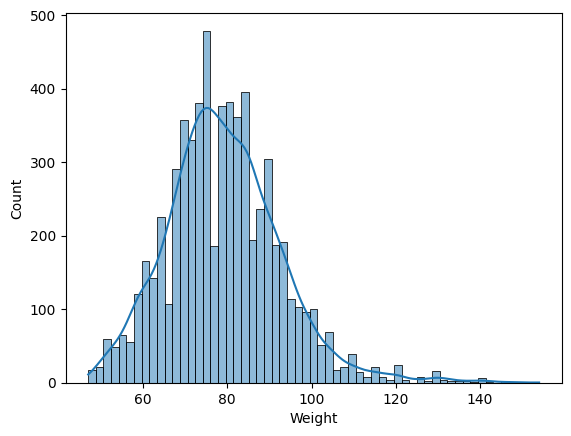

In [ ]:
# Your code here
# Мужчины, получившие серебряную медаль
silver_men = df[
    (df['Sex'] == 'M') &
    (df['Medal'] == 'Silver')
]

# Распределение веса
sns.histplot(
    data=silver_men,
    x='Weight',
    kde=True
)

**8. Постройте boxplot для возраста участника в зависимости от медали**

<Axes: xlabel='Medal', ylabel='Age'>

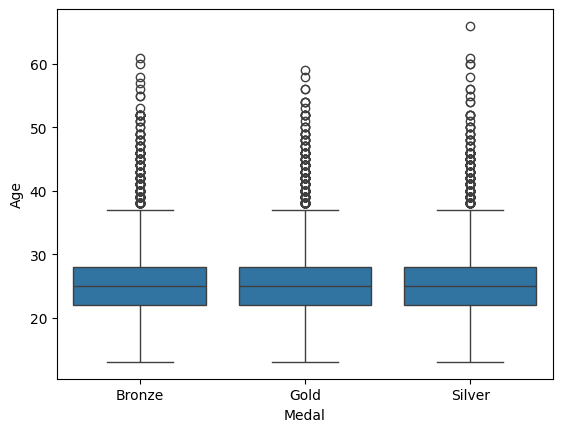

In [ ]:
# Your code here
medals_age = df.dropna(subset=['Age', 'Medal'])

# Строим boxplot
sns.boxplot(
    data=medals_age,
    x='Medal',
    y='Age'
)

**9. Постройте pairplot для веса, возраста и роста участников от USA.**

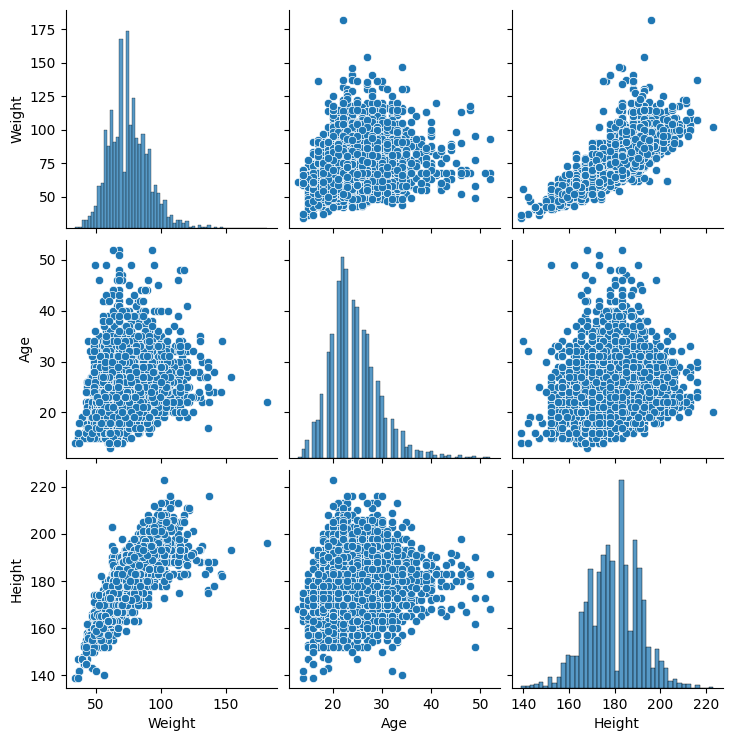

In [ ]:
# Your code here
# Оставляем только участников из USA
usa = df[df['NOC'] == 'USA']

# Выбираем нужные столбцы и убираем пропуски
usa_data = usa[['Weight', 'Age', 'Height']].dropna()

# Строим pairplot
sns.pairplot(usa_data)

### Часть 2. NLP: BoW

In [4]:
df_au = pd.read_csv("/content/author_ru_utf.csv")
df_au.head()

,Unnamed: 0,document,на,что,за,и,в,из,со,а,...,о,ко,над,без,при,об,через,из-за,из-под,Author
0,1,ГогольНВ_ВечераЧ1_1.txt,154,95,42,309,157,40,8,46,...,5,1,6,10,5,4,1,0,0,ГогольНВ
1,2,ГогольНВ_ВечераЧ1_2.txt,179,158,71,413,233,40,8,53,...,15,2,4,8,11,7,5,1,0,ГогольНВ
2,3,ГогольНВ_ВечераЧ1_3.txt,164,140,52,363,214,29,4,49,...,10,3,5,4,12,4,6,1,1,ГогольНВ
3,4,ГогольНВ_ВечераЧ2_1.txt,172,160,42,370,211,50,7,60,...,9,3,6,12,11,10,4,0,0,ГогольНВ
4,5,ГогольНВ_ВечераЧ2_2.txt,171,129,43,331,183,41,7,67,...,13,3,8,12,6,3,7,5,1,ГогольНВ


In [5]:
df_au.shape

(456, 30)

In [6]:
df_au.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456 entries, 0 to 455
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  456 non-null    int64 
 1   document    456 non-null    object
 2   на          456 non-null    int64 
 3   что         456 non-null    int64 
 4   за          456 non-null    int64 
 5   и           456 non-null    int64 
 6   в           456 non-null    int64 
 7   из          456 non-null    int64 
 8   со          456 non-null    int64 
 9   а           456 non-null    int64 
 10  во          456 non-null    int64 
 11  для         456 non-null    int64 
 12  с           456 non-null    int64 
 13  но          456 non-null    int64 
 14  к           456 non-null    int64 
 15  по          456 non-null    int64 
 16  от          456 non-null    int64 
 17  под         456 non-null    int64 
 18  до          456 non-null    int64 
 19  про         456 non-null    int64 
 20  о         

In [7]:
df_au.describe()

,Unnamed: 0,на,что,за,и,в,из,со,а,во,...,про,о,ко,над,без,при,об,через,из-за,из-под
count,456.00000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,...,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.00000
mean,228.50000,110.567982,148.342105,35.521930,365.462719,183.274123,26.129386,9.083333,63.245614,10.219298,...,7.065789,26.269737,3.717105,4.258772,9.206140,7.096491,6.515351,4.326754,1.826754,0.75000
std,131.78012,36.909985,56.245471,13.203711,125.051158,63.000344,12.215228,5.164723,29.965566,5.826818,...,5.271951,15.090192,3.582162,3.080411,4.954435,4.701123,4.787780,3.259581,1.727167,1.14786
min,1.00000,14.000000,36.000000,7.000000,52.000000,19.000000,2.000000,0.000000,9.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,114.75000,82.000000,109.000000,27.000000,282.750000,140.750000,18.000000,5.000000,42.000000,6.000000,...,3.000000,15.000000,1.000000,2.000000,6.000000,4.000000,3.000000,2.000000,1.000000,0.00000
50%,228.50000,107.000000,137.500000,34.000000,349.500000,173.000000,24.000000,8.000000,58.000000,9.000000,...,6.000000,23.000000,3.000000,4.000000,8.000000,6.000000,6.000000,4.000000,1.000000,0.00000
75%,342.25000,134.000000,176.250000,43.000000,429.500000,215.500000,32.000000,12.000000,81.000000,13.000000,...,10.000000,34.000000,5.000000,6.000000,12.000000,10.000000,9.000000,6.000000,3.000000,1.00000
max,456.00000,241.000000,433.000000,94.000000,901.000000,429.000000,84.000000,37.000000,216.000000,37.000000,...,32.000000,83.000000,29.000000,16.000000,30.000000,25.000000,26.000000,20.000000,11.000000,8.00000


**1. Какая служебная часть речи чаще всего встречается Н.В. Гоголя?**

In [14]:
# Оставляем только тексты Гоголя
gogol = df_au[df_au['Author'] == 'ГогольНВ']

# Берём столбцы со служебными словами
words = gogol.iloc[:, 2:-1]

# Суммируем количество употреблений
counts = words.sum()

# Находим самое частотное слово
index = np.argmax(counts.values)

print(counts.index[index])

и


**2. Постройте гистограмму распределения предлогов "на", "с", "в" у авторов**

<Axes: xlabel='Author'>

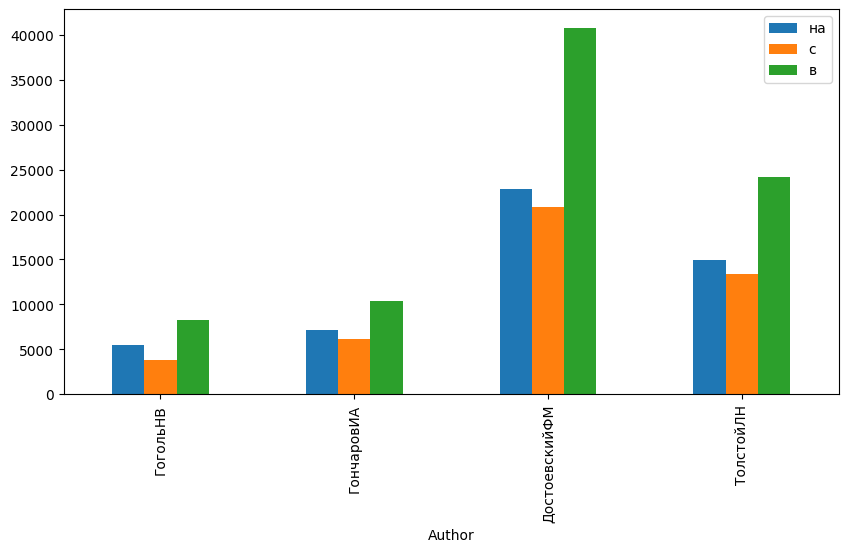

In [18]:
# Your code here
# Берём нужные столбцы
data = df_au[['Author', 'на', 'с', 'в']]

# Суммируем количество предлогов по каждому автору
data = data.groupby('Author')[['на', 'с', 'в']].sum()

# Строим гистограмму
data.plot(kind='bar', figsize=(10, 5))

**3. Постройте boxplot для предлога "из-за" для авторов**

<Axes: xlabel='Author', ylabel='из-за'>

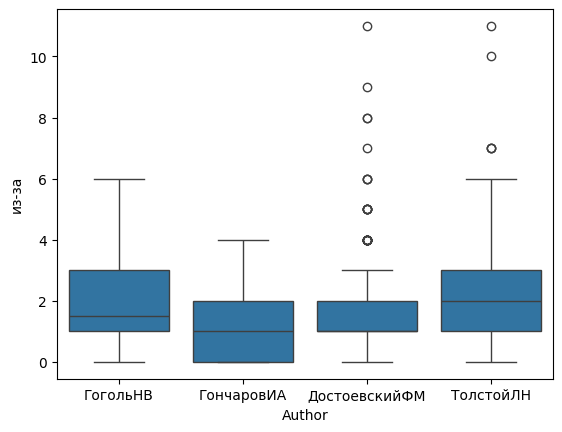

In [20]:
# Your code here
#отбираем данные
iz_za = df_au[['из-за', 'Author']]

# Строим boxplot
sns.boxplot(
    data=iz_za,
    x='Author',
    y='из-за'
)

**4. Создайте распределение предлога "за" по двум любым авторам**

<Axes: xlabel='за', ylabel='Count'>

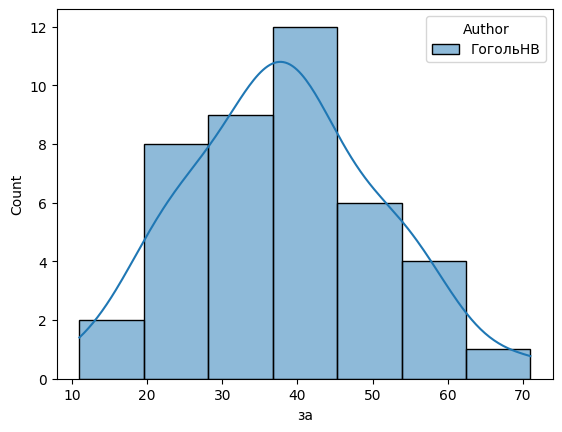

In [29]:
# Your code here
data = df_au[df_au['Author'].isin(['ГогольНВ'])]

sns.histplot(
    data=data,
    x='за',
    hue='Author',
    kde=True
)

